In [84]:
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path

base_path = Path(r'C:\Users\korol\OneDrive\Pulpit\Master\CUP - remove asymmetric, remove orbits, counting changes\result_graphs')
sns.set_theme(style="whitegrid")

What results do I need?
RANDOM GRAPHS
My algorithm works best 
1. the average number of vertices in the queue: how many vertices is being processed, compared to n

In [28]:
folders = ["one_percent", "five_percent", "twenty_percent"]
p_list = ["01", "03", "05"]
graph_type = ["tree", "random_graph"]
up_funcs = ["cor", "cas","cup"]
JSON_COLUMNS = ['n', 'm', 'graph', 'S', 'q_lens', 'q_len_average', 'coloring']

def load_json(x):
    try:
        return json.loads(x)
    except:
        return x
    
def unpack_file(folder, update_function, graph_type, p):
    if graph_type == "tree":
        path = base_path / folder / f"all_{update_function}_trees.csv"
    else:
        path = base_path / folder / f"all_{update_function}_rand_p_{p}.csv"

    df = pd.read_csv(
        path,
        converters={col: load_json for col in JSON_COLUMNS}
    )
    df = df.sort_values("n")
    return df

res_rand = {}
res_tree = {}
for folder in folders:
    res_tree[folder] = {}
    for func in up_funcs:
        res_tree[folder][func] = unpack_file(folder, func, "tree", _)
        
for p in p_list:
    res_rand[p] = {}
    for folder in folders:
        res_rand[p][folder] = {}
        for func in up_funcs:
            res_rand[p][folder][func] = unpack_file(folder, func, "random_graph", p)

In [29]:
# I want to remove the last element of the q_lens from the average
# because it is not processed 
def recompute_q_len_avg(df):
    df["q_len_average"] = df["q_lens"].apply(
        lambda x: np.mean(x[:-1]) if isinstance(x, list) and len(x) > 1 else np.nan
    )

# -------- random graphs --------
for p in p_list:
    for folder in folders:
        for func in up_funcs:
            recompute_q_len_avg(res_rand[p][folder][func])

# -------- trees --------
for folder in res_tree:
    for func in up_funcs:
        recompute_q_len_avg(res_tree[folder][func])


1. Average length of the queue.

In [62]:
# results: folder -> cup, cas, cor -> dfs
def plot_average_q_len(results, _title, lines_a=False, lims=[(0,500), (0,500), (0,500)]):
    sns.set_theme(context="notebook", style="whitegrid")
    folders = ["one_percent", "five_percent", "twenty_percent"]

    fig, axes = plt.subplots(
        nrows=1,
        ncols=3,   # or however many panels you have
        sharey=True,
        figsize=(15, 5),
        constrained_layout=True
    )
    for i in range(3):
        f = folders[i]
        dfs = results[f] # keys: cup, cas, cor
        n_list = dfs["cup"]["n"]
        ax = axes[i]
        cup = [avg for _, avg in zip(n_list, dfs["cup"]["q_len_average"])]
        cas = [avg for _, avg in zip(n_list, dfs["cas"]["q_len_average"])]
        cor = [avg for _, avg in zip(n_list, dfs["cor"]["q_len_average"])]

        df = pd.DataFrame({
            "n": n_list,
            "cup": cup,
            "cas": cas,
            "cor": cor
        })
        df_long = df.melt(id_vars='n', var_name='algorithm', value_name='avg_q_len')
        sns.scatterplot(data=df_long, x="n", y="avg_q_len", hue="algorithm", ax=ax)
        ax.plot(n_list, n_list, linestyle="--", label="n", color="orange")
        if lines_a:
            a = lines_a[i]
            ax.plot(n_list, a * n_list, linestyle="--", label=f"{a}·n", color="blue")

        ax.set_title(f"percent of changed edges = {f}")
        ax.set_xlabel("n")
        ax.set_ylabel("avg q len")
        ax.legend(title="algorithm", fontsize=9)
        ax.set_xlim(lims[i][0], lims[i][1])
        ax.set_ylim(lims[i][0], lims[i][1])

    fig.suptitle(_title, fontsize=14)
    plt.show()



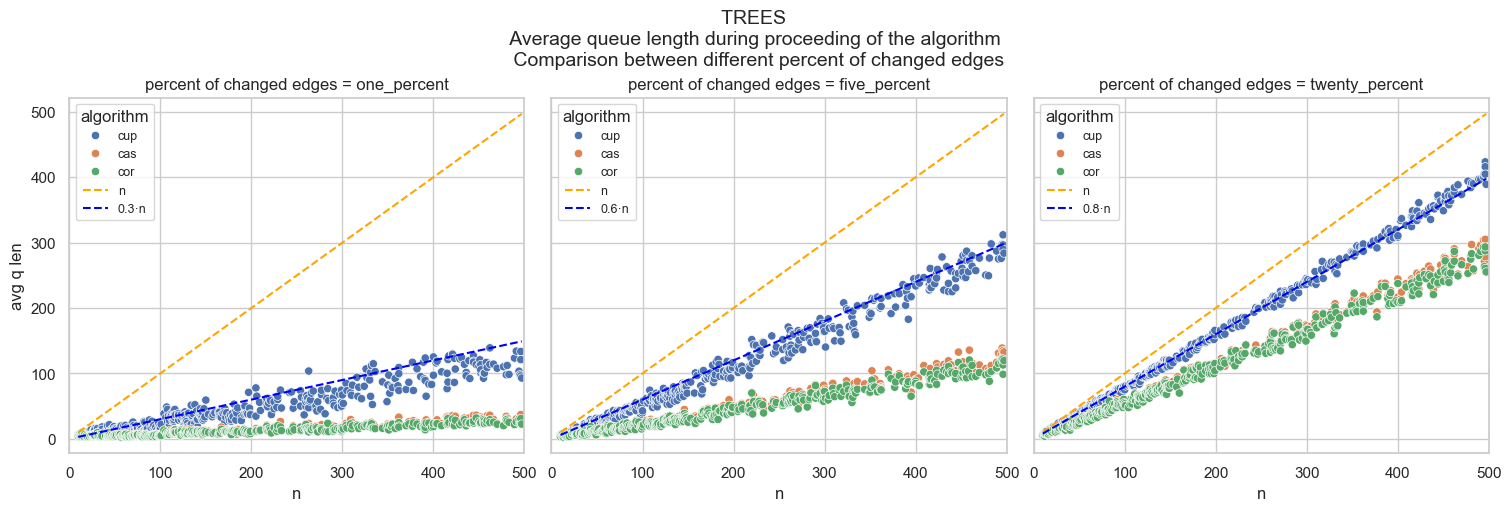

In [48]:
# Trees - average q length
results = res_tree
lines_a = [0.3, 0.6, 0.8]
_title ="TREES \n Average queue length during proceeding of the algorithm \n Comparison between different percent of changed edges"
plot_average_q_len(results, _title, lines_a)

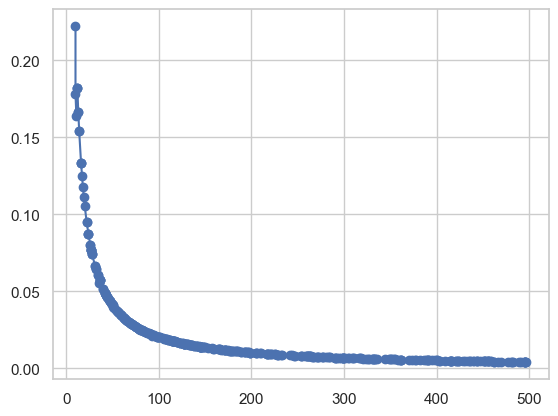

In [83]:
df = res_tree["one_percent"]["cup"]
plt.plot(df["n"], 2*df["m"] / ((df["n"])*(df["n"]-1)), marker="o")
#pd.set_option("display.max_rows", None)
#print(df[["n","q_lens"]])

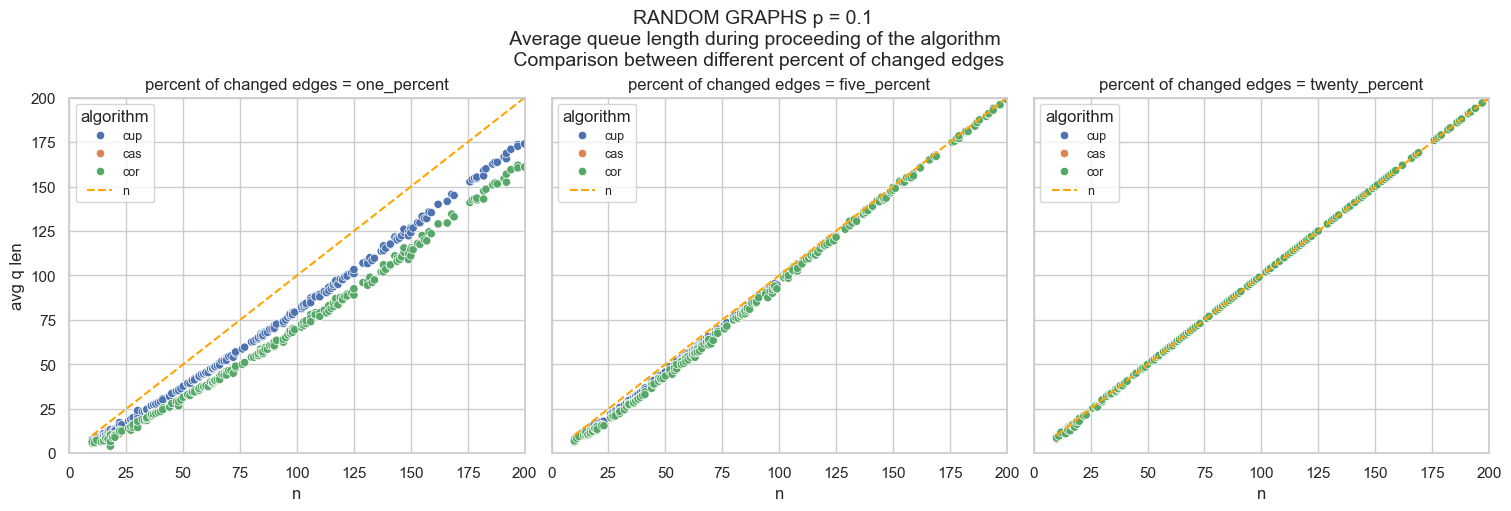

In [76]:
# Random graphs with density of edges p = 0.1
# Trees - average q length
results = res_rand["05"]
lims = [(0,200), (0,200), (0,200)]
#lines_a = [1, 1, 1]
_title =f"RANDOM GRAPHS p = 0.1 \n Average queue length during proceeding of the algorithm \n Comparison between different percent of changed edges"
plot_average_q_len(results, _title, lims=lims)

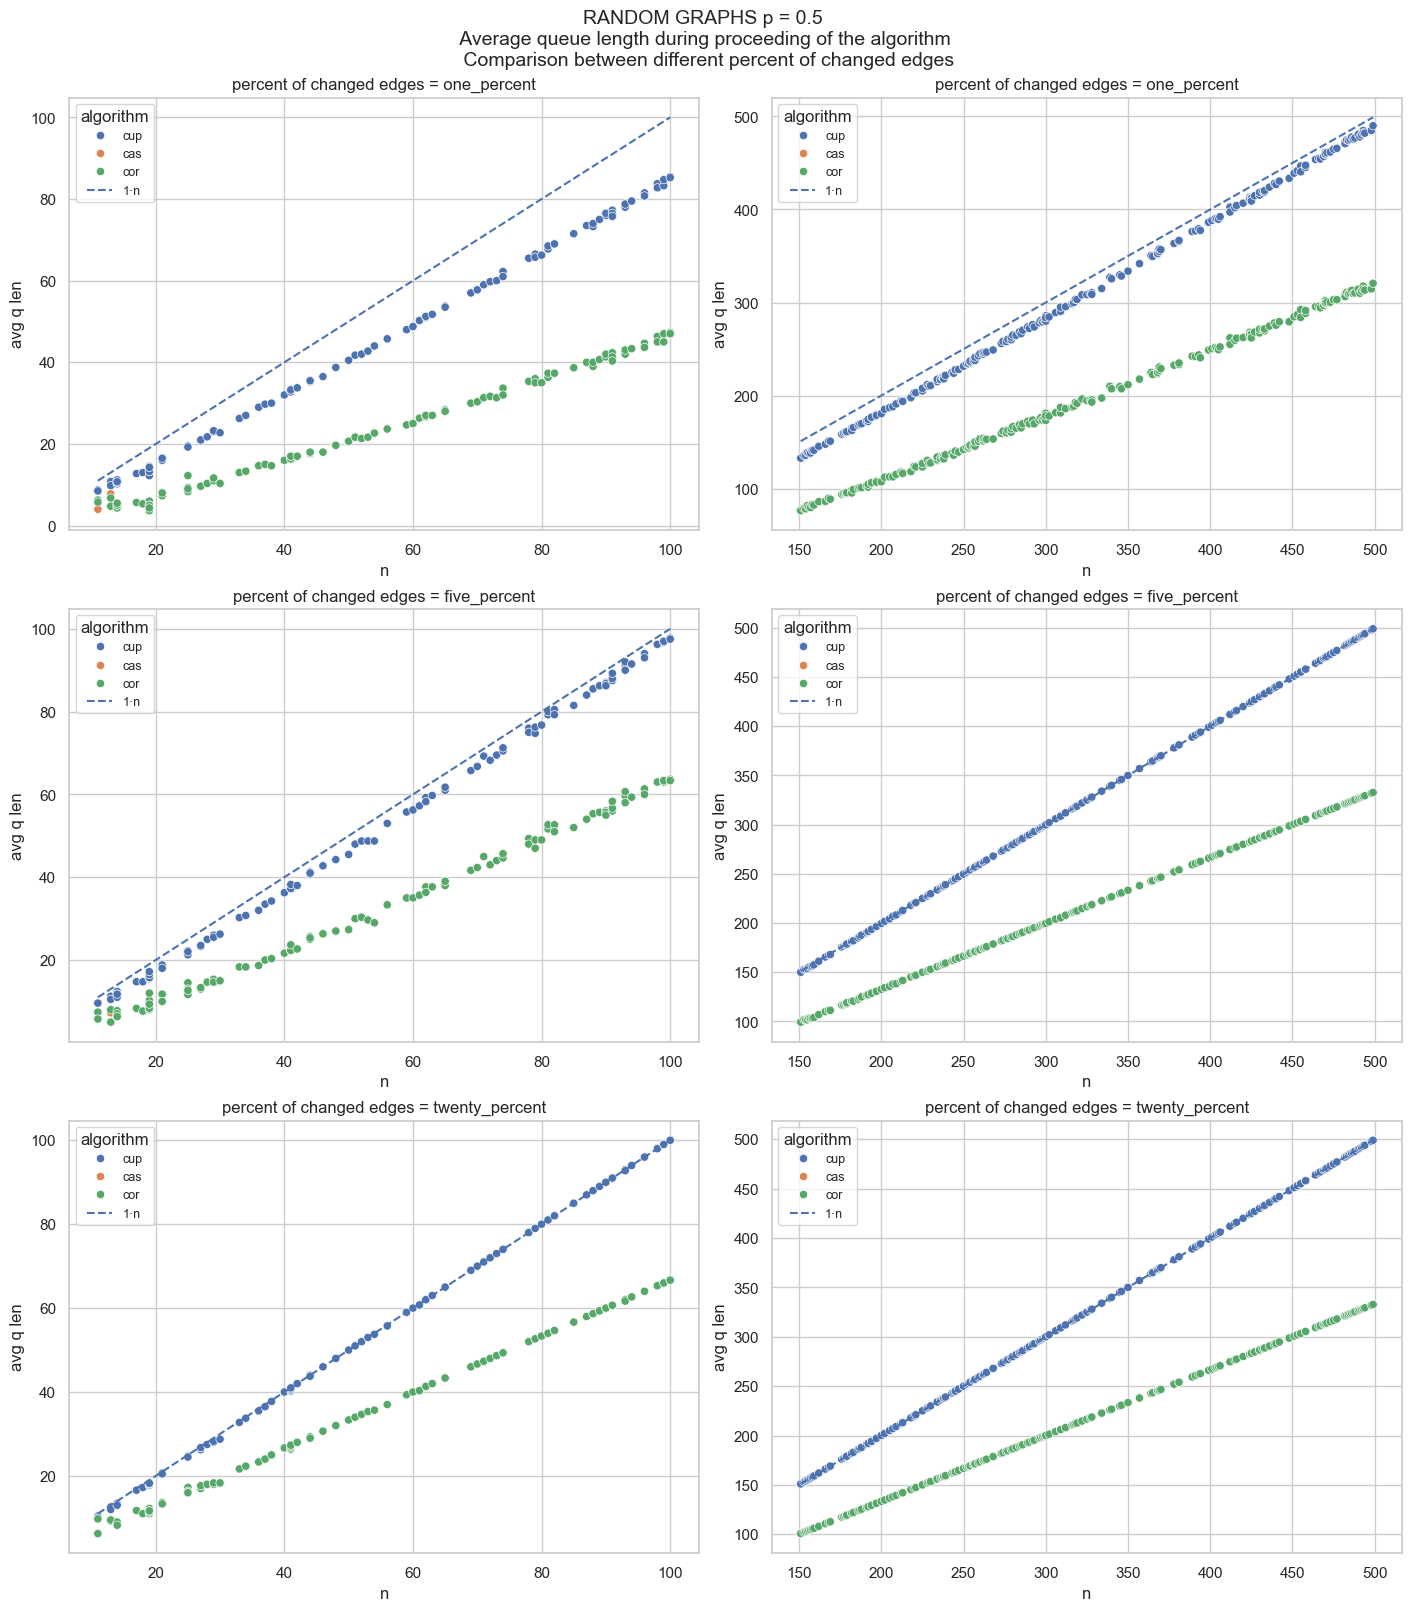

In [ ]:
sns.set_theme(context="notebook", style="whitegrid")

lims = [(10, 500)]
lines_a = [1,1,1]#[0.3, 0.6, 0.8]
graph_type = "random_graph"
p = p_list[2]

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(14, 16), constrained_layout=True)

for row_idx, f_nr in enumerate([0, 1, 2]):
    a = lines_a[f_nr]
    results = load_merged_df(f_nr, graph_type, p)
    for col_idx, lim, res in zip([0,1], lims, results):
        ax = axes[row_idx, col_idx] 

        n_list = res["cup"]["n"]
        cup = res["cup"]["q_len_average"]
        cas = res["cas"]["q_len_average"]
        cor = res["cor"]["q_len_average"]

        df = pd.DataFrame({
            "n": n_list,
            "cup": cup,
            "cas": cas,
            "cor": cor
        })
        df_long = df.melt(id_vars='n', var_name='algorithm', value_name='avg_q_len')
        sns.scatterplot(data=df_long, x="n", y="avg_q_len", hue="algorithm", ax=ax)
        ax.plot(n_list, a * n_list, linestyle="--", label=f"{a}·n")

        ax.set_title(f"percent of changed edges = {folders[f_nr]}")
        ax.set_xlabel("n")
        ax.set_ylabel("avg q len")
        ax.legend(title="algorithm", fontsize=9)

fig.suptitle(f"RANDOM GRAPHS p = {p} \n Average queue length during proceeding of the algorithm \n Comparison between different percent of changed edges", fontsize=14)
plt.show()



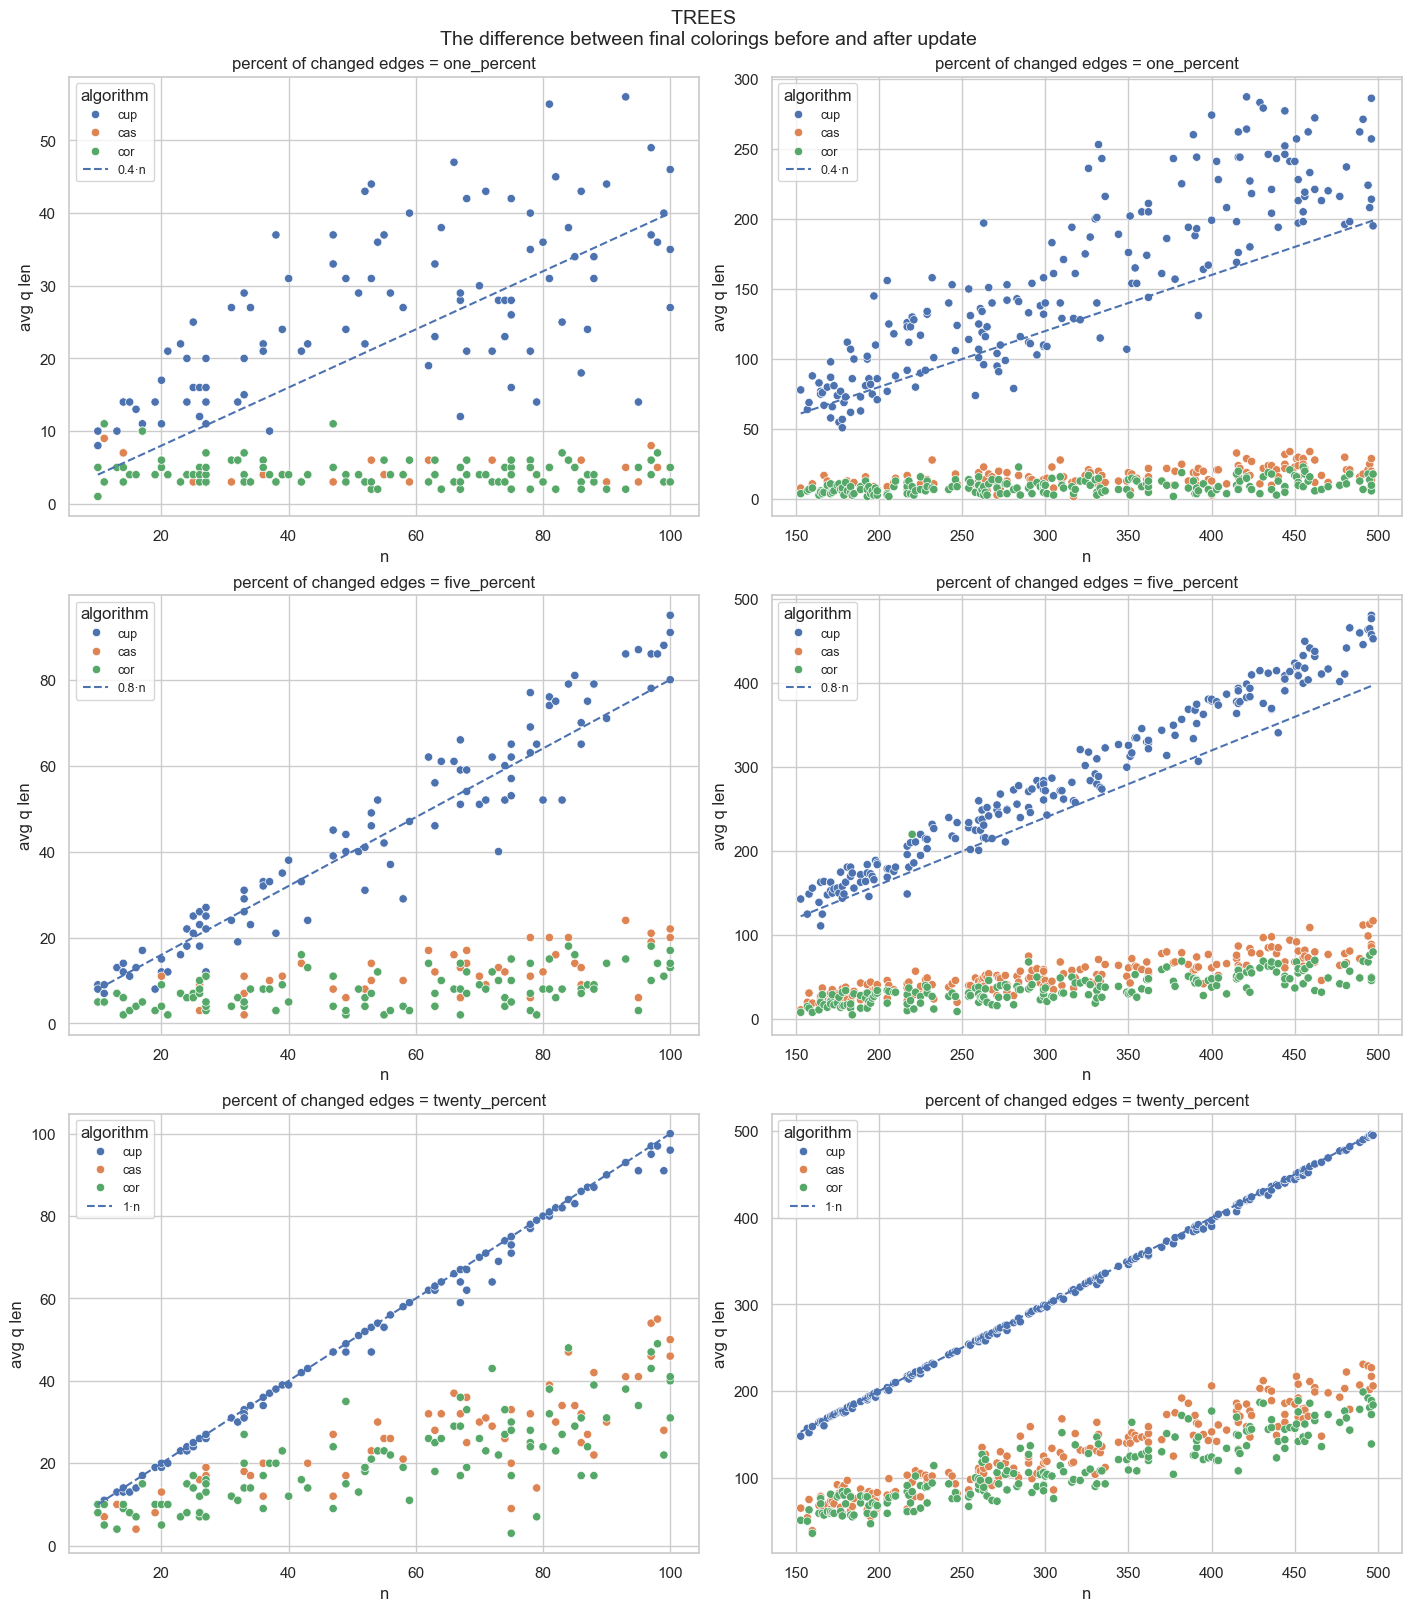

In [26]:
# differences

sns.set_theme(context="notebook", style="whitegrid")

lims = [(10,100), (150, 500)]
lines_a = [0.4, 0.8, 1]
graph_type = "tree"
p = 0

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 16), constrained_layout=True)

for row_idx, f_nr in enumerate([0, 1, 2]):
    a = lines_a[f_nr]
    results = load_merged_df(f_nr, graph_type, 0)
    for col_idx, lim, res in zip([0,1], lims, results):
        ax = axes[row_idx, col_idx] 

        n_list = res["cup"]["n"]
        cup = [q[-2] for q in res["cup"]["q_lens"]]
        cas = [q[-2] for q in res["cas"]["q_lens"]]
        cor = [q[-2] for q in res["cor"]["q_lens"]]

        df = pd.DataFrame({
            "n": n_list,
            "cup": cup,
            "cas": cas,
            "cor": cor
        })
        df_long = df.melt(id_vars='n', var_name='algorithm', value_name='avg_q_len')
        sns.scatterplot(data=df_long, x="n", y="avg_q_len", hue="algorithm", ax=ax)
        ax.plot(n_list, a * n_list, linestyle="--", label=f"{a}·n")

        ax.set_title(f"percent of changed edges = {folders[f_nr]}")
        ax.set_xlabel("n")
        ax.set_ylabel("avg q len")
        ax.legend(title="algorithm", fontsize=9)

fig.suptitle("TREES \n The difference between final colorings before and after update", fontsize=14)
plt.show()




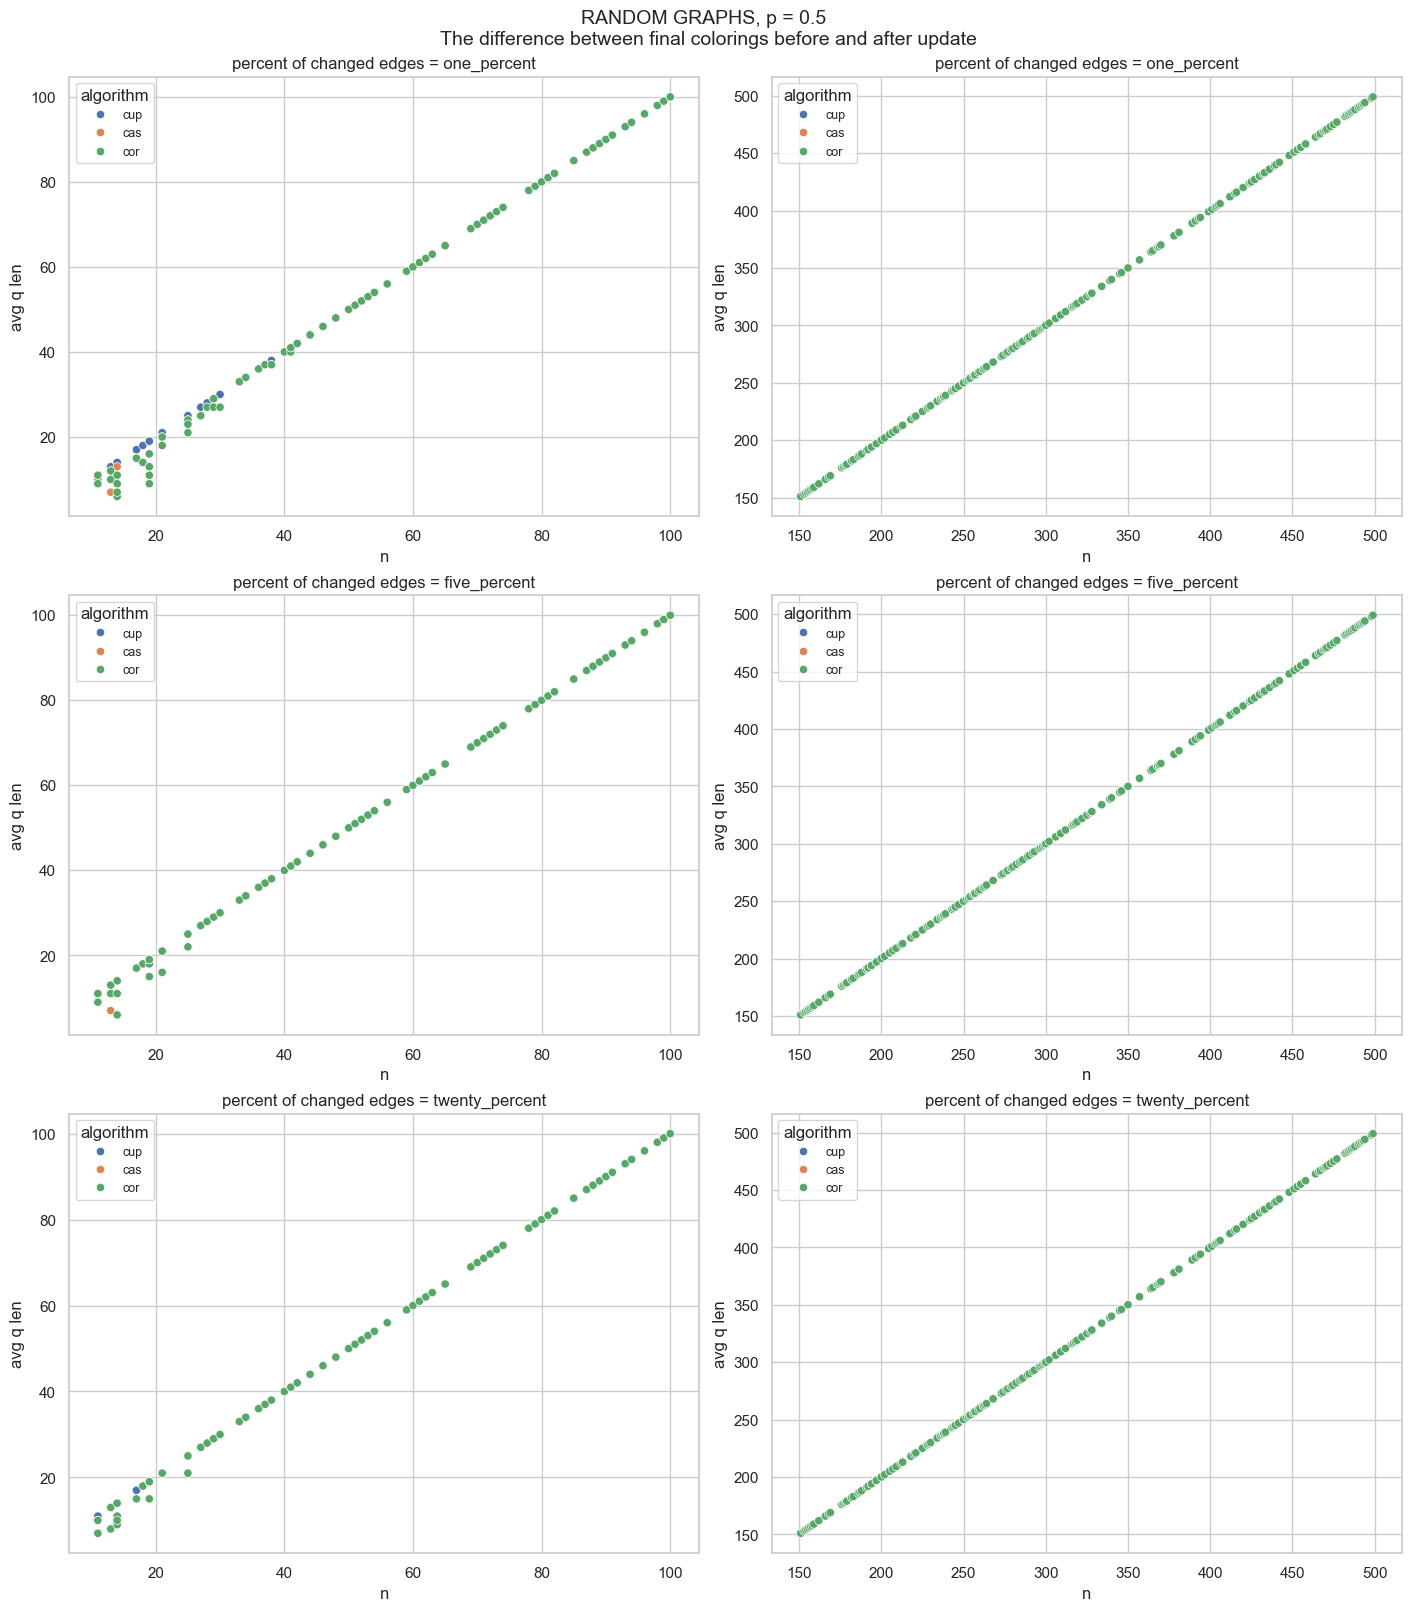

In [29]:
# differences

sns.set_theme(context="notebook", style="whitegrid")

lims = [(10,100), (150, 500)]
lines_a = [1, 1, 1]
graph_type = "random_graph"
p = p_list[2]

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 16), constrained_layout=True)

for row_idx, f_nr in enumerate([0, 1, 2]):
    a = lines_a[f_nr]
    results = load_merged_df(f_nr, graph_type, p)
    for col_idx, lim, res in zip([0,1], lims, results):
        ax = axes[row_idx, col_idx] 

        n_list = res["cup"]["n"]
        cup = [q[-2] for q in res["cup"]["q_lens"]]
        cas = [q[-2] for q in res["cas"]["q_lens"]]
        cor = [q[-2] for q in res["cor"]["q_lens"]]
        
        df = pd.DataFrame({
            "n": n_list,
            "cup": cup,
            "cas": cas,
            "cor": cor
        })
        df_long = df.melt(id_vars='n', var_name='algorithm', value_name='avg_q_len')
        sns.scatterplot(data=df_long, x="n", y="avg_q_len", hue="algorithm", ax=ax)
        #ax.plot(n_list, a * n_list, linestyle="--", label=f"{a}·n")

        ax.set_title(f"percent of changed edges = {folders[f_nr]}")
        ax.set_xlabel("n")
        ax.set_ylabel("avg q len")
        ax.legend(title="algorithm", fontsize=9)

fig.suptitle(f"RANDOM GRAPHS, p = {p} \n The difference between final colorings before and after update", fontsize=14)
plt.show()